In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score 

from sklearn.datasets import load_wine

In [3]:
df = load_wine(as_frame=True)
df = df.frame
df.head(70)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1
66,13.11,1.01,1.70,15.0,78.0,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502.0,1
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1
68,13.34,0.94,2.36,17.0,110.0,2.53,1.30,0.55,0.42,3.17,1.02,1.93,750.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [5]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


| Колонка                      | Перевод                      | Описание                                                    |
| ---------------------------- | ---------------------------- | ----------------------------------------------------------- |
| alcohol                      | Алкоголь                     | Содержание спирта в вине (%)                                |
| malic_acid                   | Молочная кислота             | Содержание кислоты, влияет на вкус                          |
| ash                          | Зола                         | Минеральные вещества после сгорания вина                    |
| alcalinity_of_ash            | Щёлочность золы              | Способность золы нейтрализовать кислоту                     |
| magnesium                    | Магний                       | Минеральный элемент (мг/л)                                  |
| total_phenols                | Общие фенолы                 | Влияют на вкус и антиоксидантные свойства                   |
| flavanoids                   | Флавоноиды                   | Антиоксиданты, влияют на цвет и вкус                        |
| nonflavanoid_phenols         | Нефлавоноидные фенолы        | Другие фенолы, не относящиеся к флавоноидам                 |
| proanthocyanins              | Проантоцианины               | Влияют на вкус, цвет и терпкость                            |
| color_intensity              | Интенсивность цвета          | Насколько тёмный или насыщенный цвет вина                   |
| hue                          | Оттенок                      | Соотношение красного/жёлтого оттенка вина                   |
| od280/od315_of_diluted_wines | OD280/OD315 разбавленных вин | Показатель фенольного состава, измеряется спектрофотометром |
| proline                      | Пролин                       | Аминокислота, связана с качеством и сортом винограда        |
| target                       | Целевая переменная           | Тип вина: 0, 1 или 2                                        |


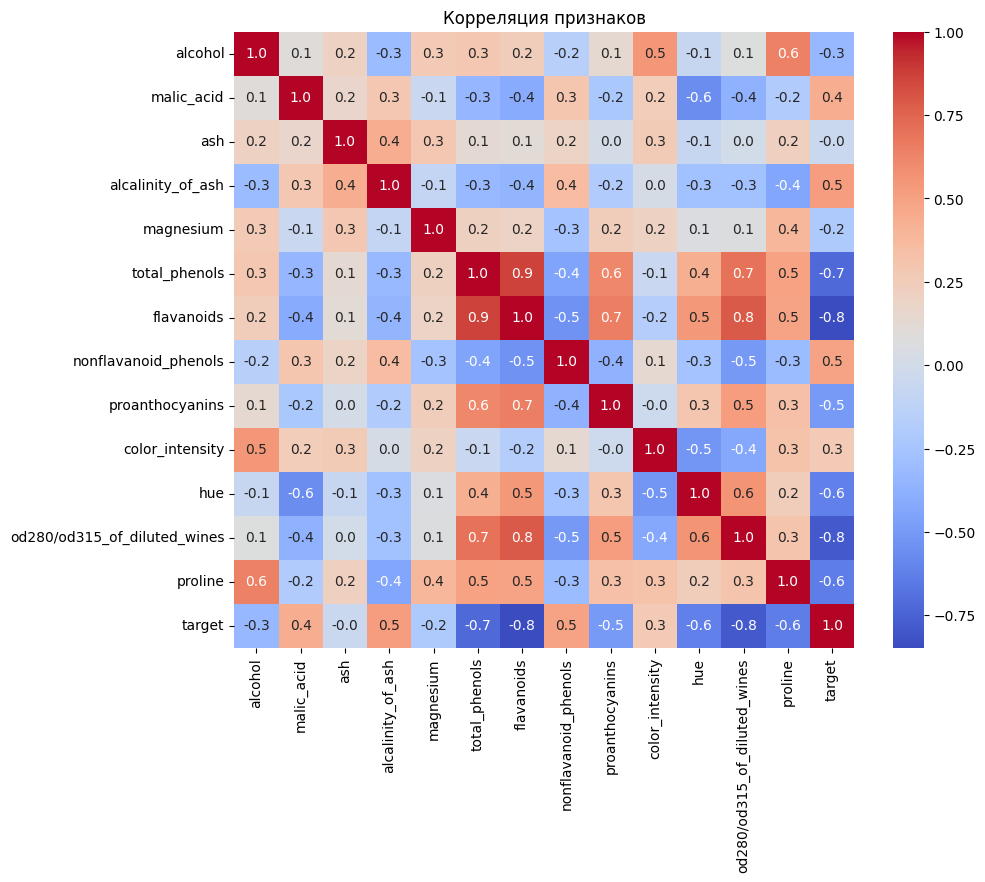

In [7]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Корреляция признаков")
plt.show()

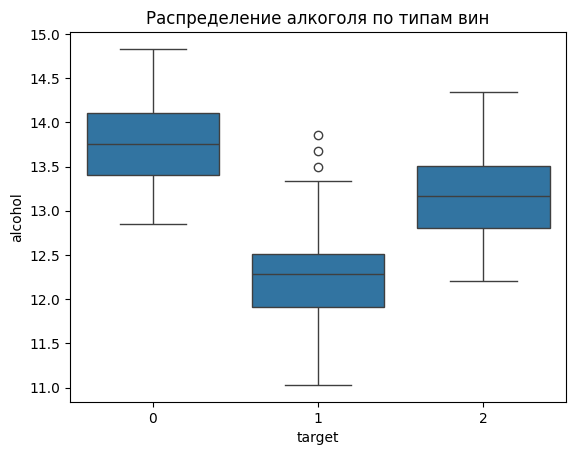

In [14]:
sns.boxplot(x='target', y='alcohol', data=df)
plt.title("Распределение алкоголя по типам вин")
plt.show()

/tmp/ipykernel_115926/1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_115926/1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_115926/1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_115926/1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

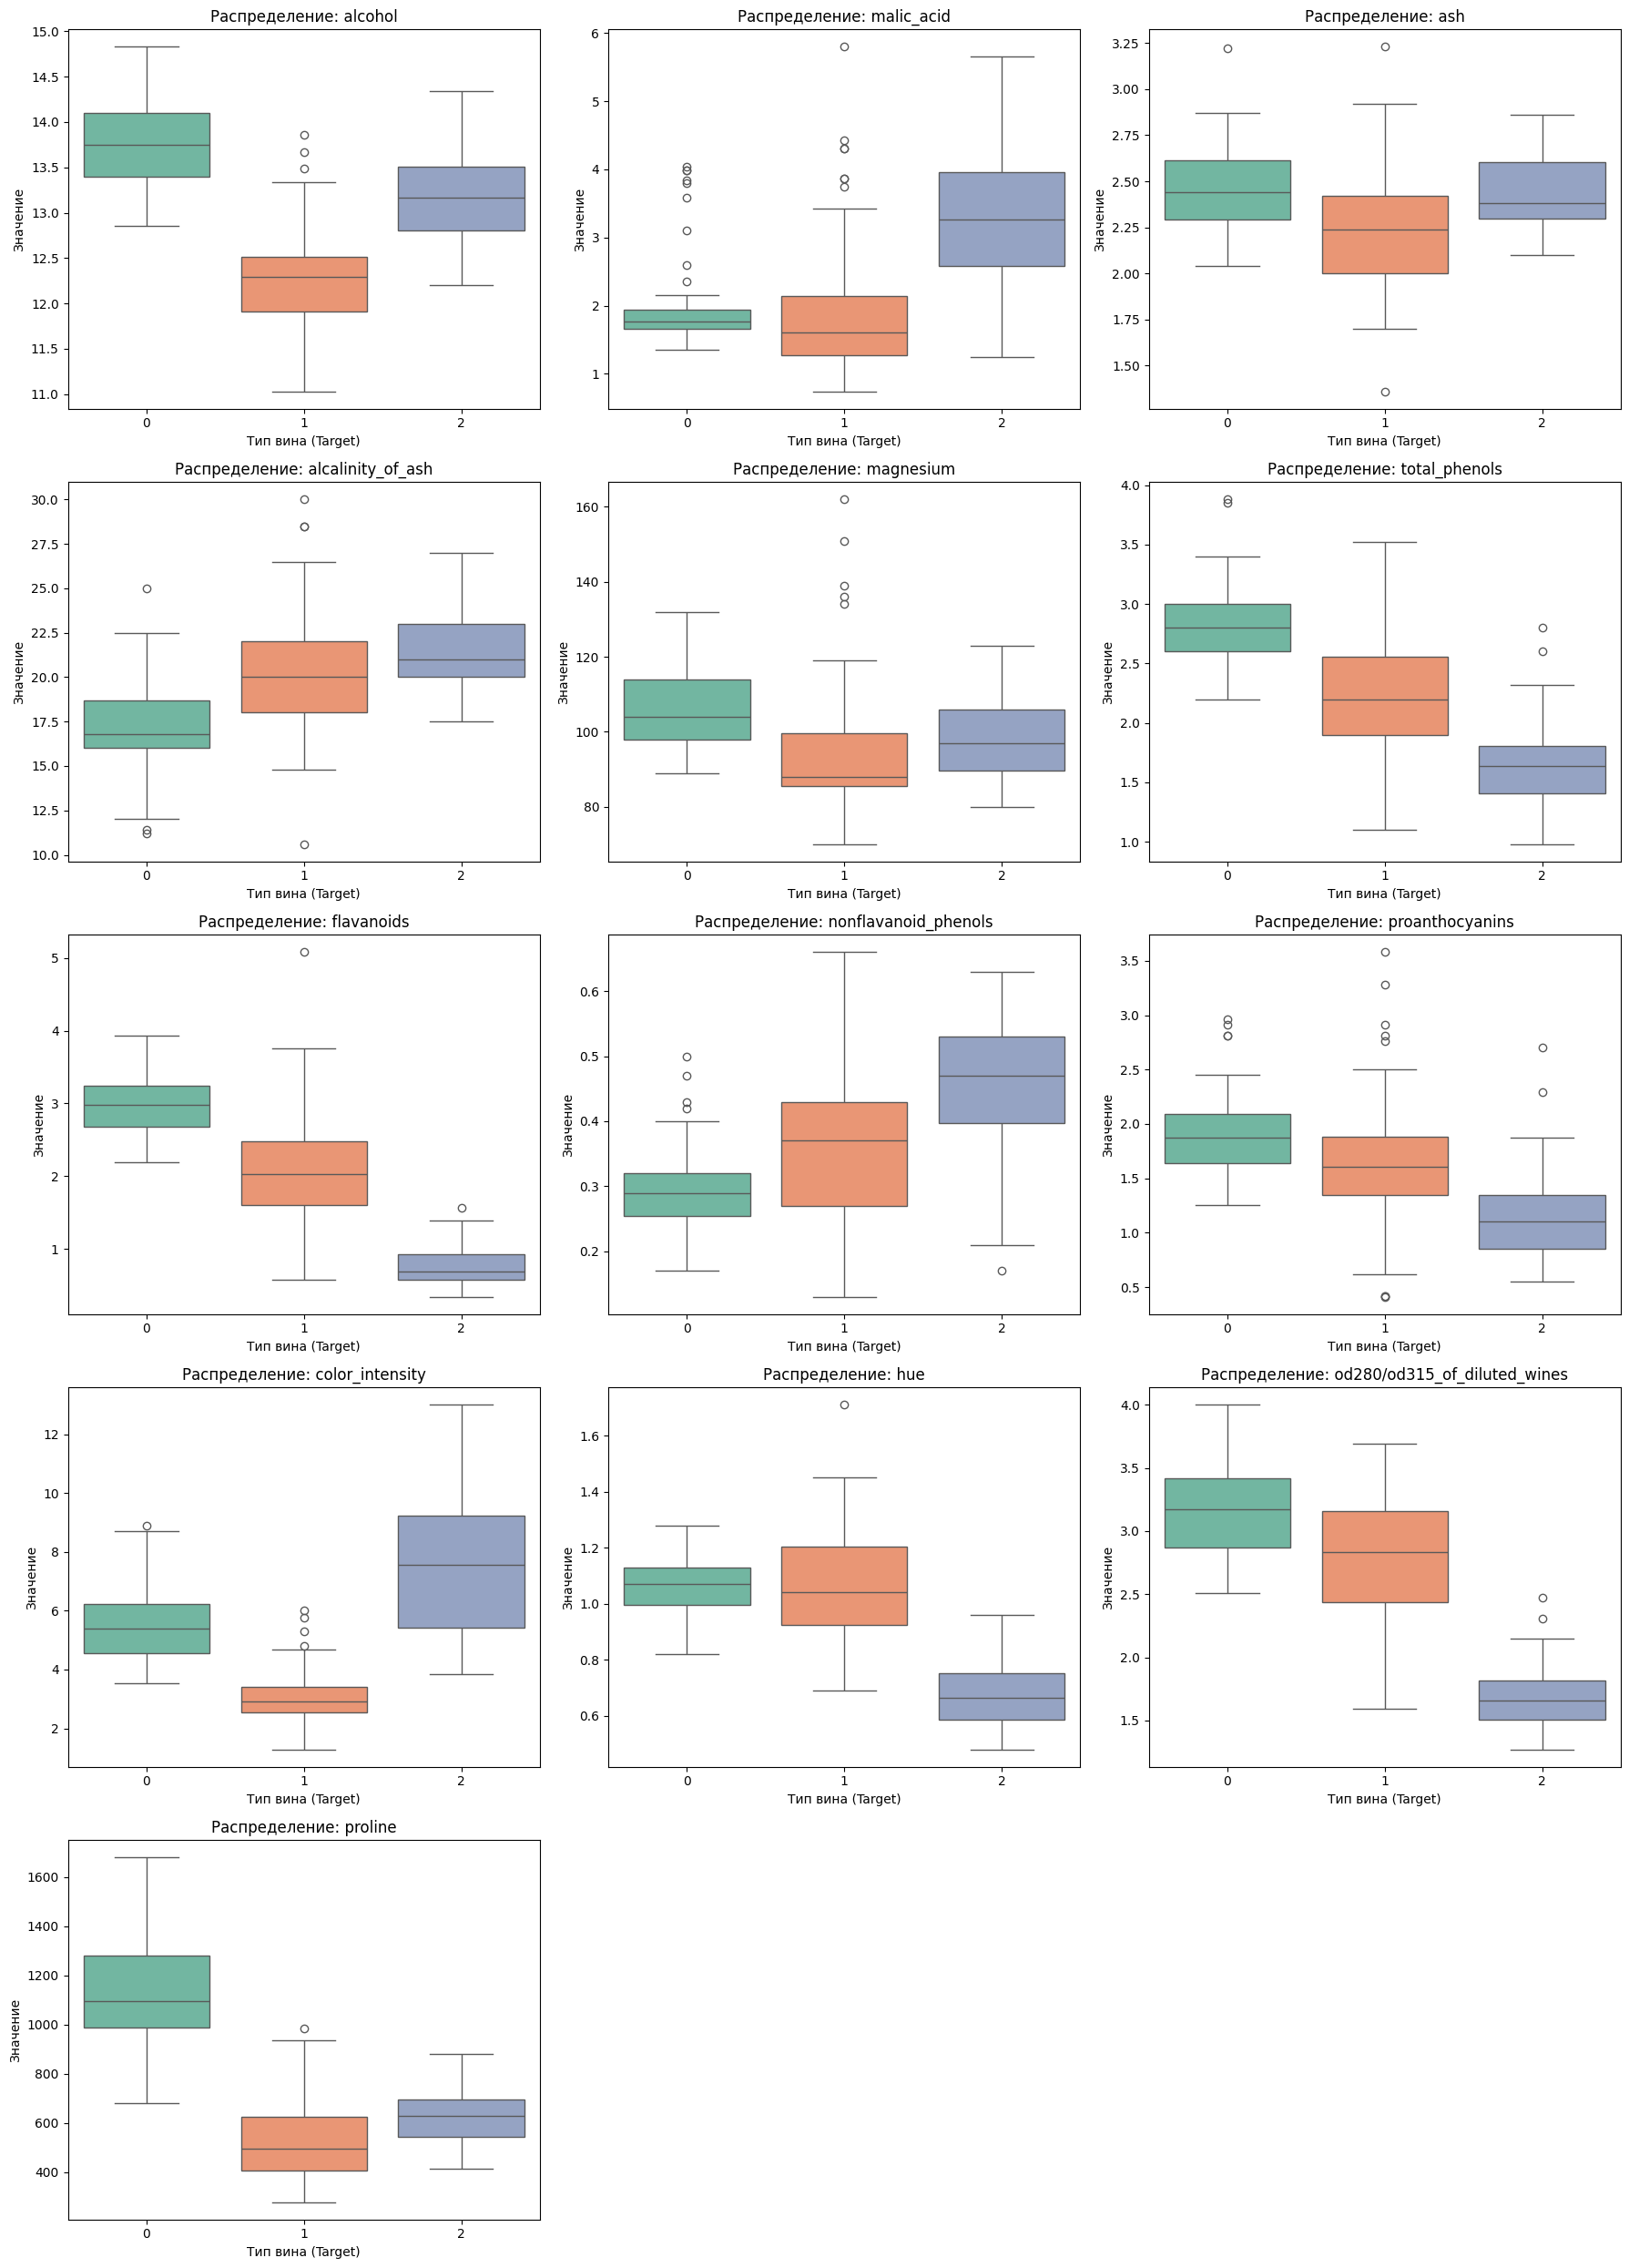

In [15]:
features = df.columns.drop('target')

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel('Тип вина (Target)')
    axes[i].set_ylabel('Значение')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
 
knn = KNeighborsClassifier(n_neighbors=5)
 
knn.fit(X_train_scaled, y_train)
 
knn_pred = knn.predict(X_test_scaled)

print(f"Точность kNN: {accuracy_score(y_test, knn_pred):.4f}")

Точность kNN: 0.9444


              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



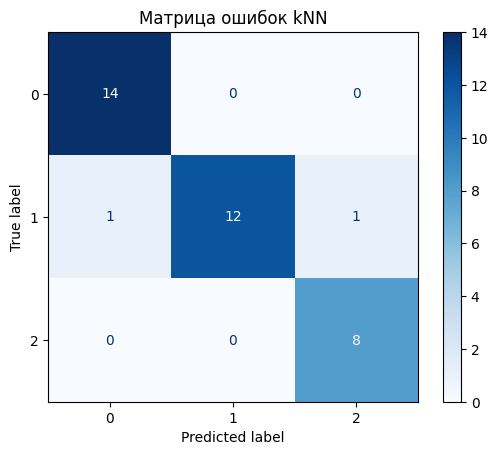

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
 
print(classification_report(y_test, knn_pred))
 
cm = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок kNN')
plt.show()

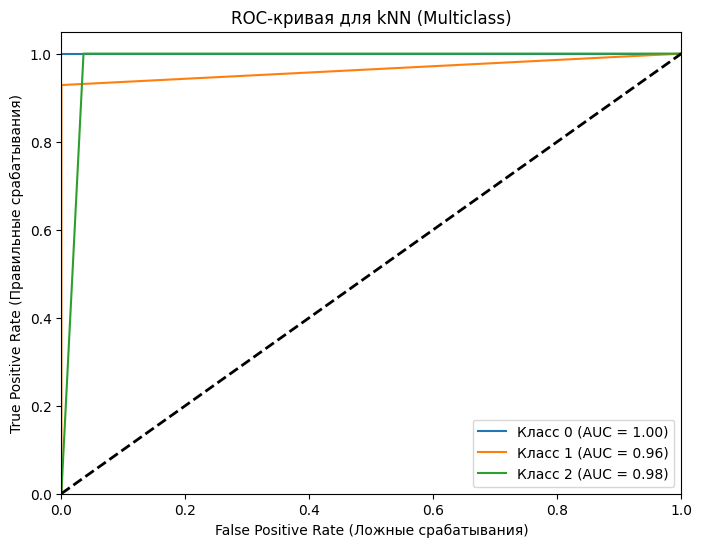

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
 
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
 
y_score = knn.predict_proba(X_test_scaled)
 
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Класс {i} (AUC = {roc_auc:.2f})')

 
plt.plot([0, 1], [0, 1], 'k--', lw=2)  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Правильные срабатывания)')
plt.title('ROC-кривая для kNN (Multiclass)')
plt.legend(loc="lower right")
plt.show()

In [22]:
new_wine_data = [13.7, 1.8, 2.3, 16.0, 110.0, 2.5, 2.3, 0.3, 1.8, 5.2, 1.1, 3.2, 1000.0]
 
new_wine_array = np.array([new_wine_data])
new_wine_array

array([[1.37e+01, 1.80e+00, 2.30e+00, 1.60e+01, 1.10e+02, 2.50e+00,
        2.30e+00, 3.00e-01, 1.80e+00, 5.20e+00, 1.10e+00, 3.20e+00,
        1.00e+03]])

In [23]:
new_wine_scaled = scaler.transform(new_wine_array)
new_wine_scaled

/home/baikadamov/Projects/Linear-Regression-kNN/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 0.88215275, -0.50313337, -0.2186842 , -1.00889827,  0.65458339,
         0.33190692,  0.29770041, -0.53223472,  0.33007697,  0.06130566,
         0.61566662,  0.84378641,  0.87999768]])

In [24]:
from sklearn.datasets import load_wine
raw_data = load_wine()
target_names = raw_data.target_names
 

prediction = knn.predict(new_wine_scaled) 
probability = knn.predict_proba(new_wine_scaled)


print(f"Предсказанный сорт: {target_names[prediction[0]]}")
print(f"Вероятности по классам: {probability[0]}")

Предсказанный сорт: class_0
Вероятности по классам: [1. 0. 0.]
